# Описание датасета


Медицина (ментальное здоровье), [Mental Health & Burnout Prediction Dataset](https://www.kaggle.com/datasets/mobeenfatimah/mental-health-and-burnout-prediction-dataset), синтетический датасет.


## Атрибуты датасета



| Атрибут | Тип | Что обозначает | Значения / диапазон |
|---|---|---|---|
| Age | числовой (целый) | возраст, лет | 18–65 |
| Monthly_Income_USD | числовой (целый) | месячный доход, USD | 500–12000 |
| Work_Hours_Per_Week | числовой (целый) | рабочих часов в неделю | 20–70 |
| Remote_Work | категориальный (строковый) | формат работы: удалённая, гибрид или офис | Yes / Hybrid / No |
| Job_Satisfaction | числовой (порядковая шкала) | удовлетворённость работой | 1–10 |
| Sleep_Hours | числовой (вещественный) | часов сна в сутки | 4–10 |
| Depression_Score | числовой (целый) | выраженность депрессивных симптомов, чем выше, тем хуже | 0–100 |
| Mood_Score | числовой (целый) | оценка настроения, чем выше, тем лучше | 0–100 |
| Emotional_Stability | числовой (целый) | эмоциональная устойчивость | 0–100 |
| Physical_Activity_Hours | числовой (вещественный) | часов физической активности (вероятно, в неделю) | 0–10 |
| Screen_Time_Hours | числовой (вещественный) | часов экранного времени (вероятно, в сутки) | 2–14 |
| Life_Satisfaction | числовой (порядковая шкала) | удовлетворённость жизнью | 1–10 |
| Mental_Health_Status | категориальный (строковый, порядковый) | целевая переменная: состояние ментального здоровья | Healthy (25 369), Needs Attention (14 096), Critical (10 535) |

Описания задачи анализа нет.

# Характеристики атрибутов

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("mental_health_dataset.csv")

df["Mental_Health_Status"] = df["Mental_Health_Status"].map(
    {
        "Healthy": 2,
        "Needs Attention": 1,
        "Critical": 0
    }
)

df["Remote_Work"] = df["Remote_Work"].map({"No": 0, "Hybrid": 1, "Yes": 2})

In [92]:
for col in df.columns:
    print(f"{col}: \n\t Cреднее: {df[col].mean()}\n\t СКО: {df[col].std()}")

Age: 
	 Cреднее: 41.448180904522616
	 СКО: 13.871634288770771
Monthly_Income_USD: 
	 Cреднее: 6251.281524201854
	 СКО: 3319.6614352520546
Work_Hours_Per_Week: 
	 Cреднее: 44.94616
	 СКО: 14.729024412282124
Remote_Work: 
	 Cреднее: 0.9988
	 СКО: 0.8164140436309341
Job_Satisfaction: 
	 Cреднее: 5.499050505050505
	 СКО: 2.8666214686090905
Sleep_Hours: 
	 Cреднее: 6.997445463812436
	 СКО: 1.7287663815076755
Depression_Score: 
	 Cреднее: 40.60115971515768
	 СКО: 26.308932565443264
Mood_Score: 
	 Cреднее: 59.62299389002037
	 СКО: 25.783486334817365
Emotional_Stability: 
	 Cреднее: 59.3821
	 СКО: 26.090946213954886
Physical_Activity_Hours: 
	 Cреднее: 4.9880347648261765
	 СКО: 2.8700144507158734
Screen_Time_Hours: 
	 Cреднее: 7.991273652085454
	 СКО: 3.4724981567867905
Life_Satisfaction: 
	 Cреднее: 5.52129817444219
	 СКО: 2.868514345357366
Mental_Health_Status: 
	 Cреднее: 1.29668
	 СКО: 0.7937717424244713


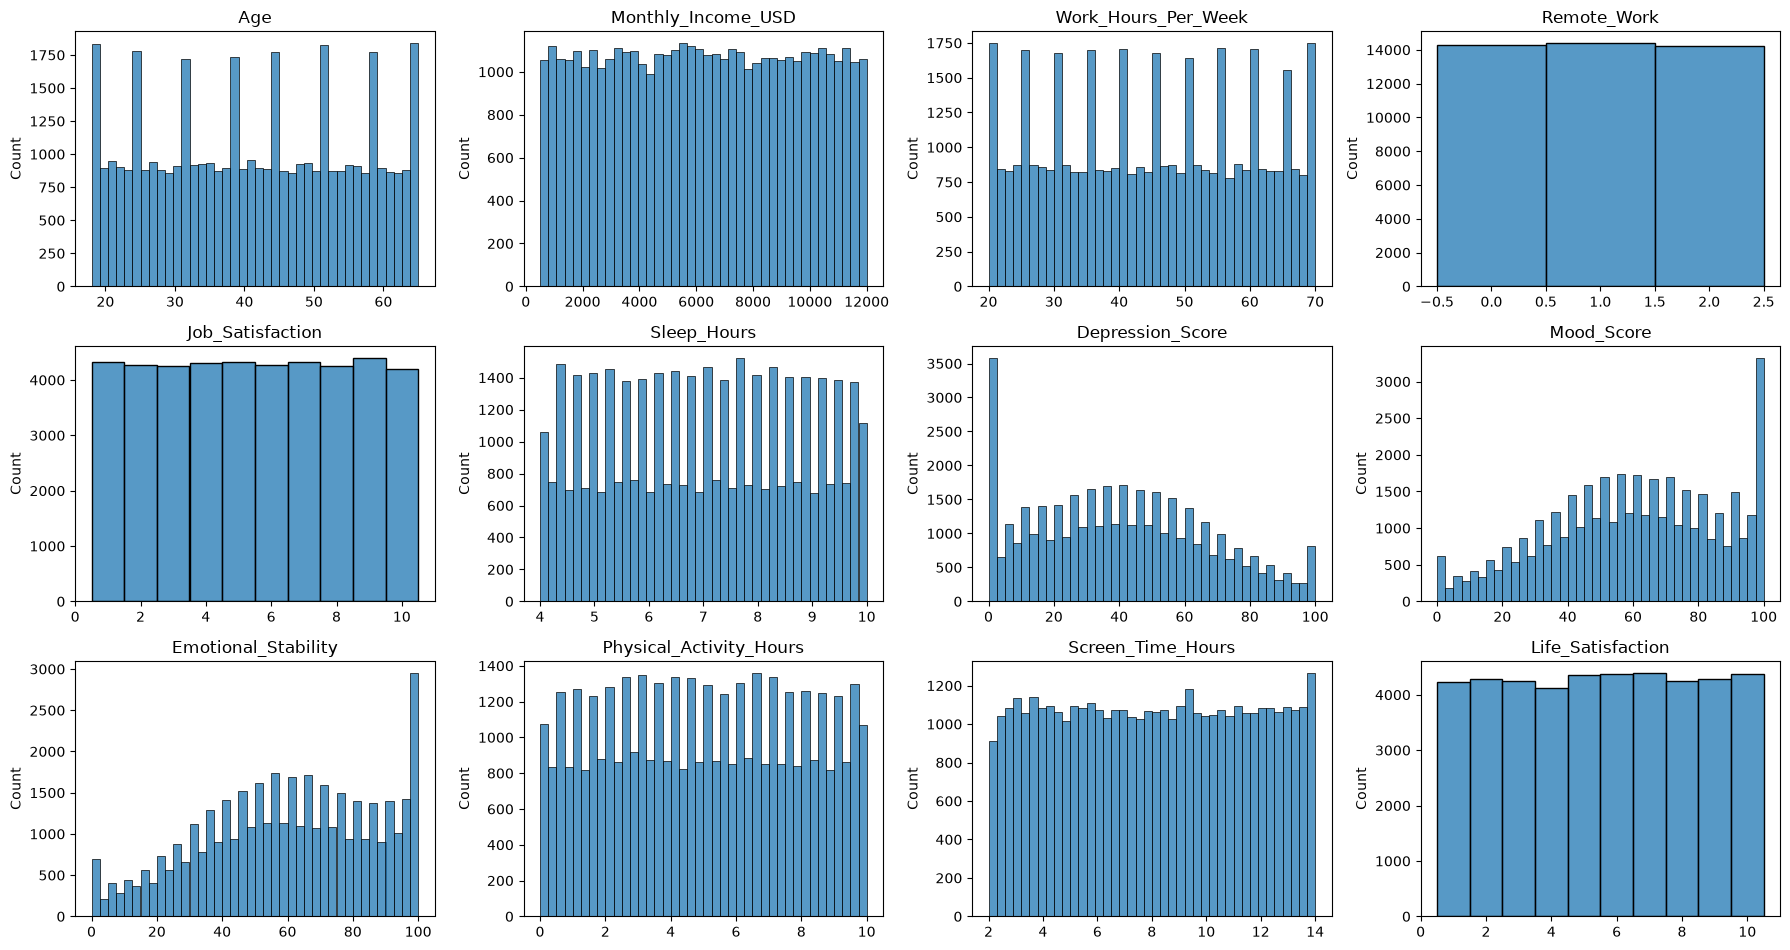

In [100]:
cols = df.columns
nrows = len(cols) // 4

fig, axes = plt.subplots(nrows, 4, figsize=(18, 3.2 * nrows))
for ax, col in zip(axes.flat, cols):
    s = df[col].dropna()
    numeric = s.dtype.kind in "if"
    if not numeric:
        sns.histplot(s, ax=ax)
    elif (s % 1 == 0).all() and s.nunique() <= 40:
        sns.histplot(s, discrete=True, ax=ax)
    else:
        sns.histplot(s, bins=40, ax=ax)

    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes.flat[len(cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [94]:
print("Пропуски:")
for col in df.columns:
    print(f"{col}: {len(df[df[col].isna()])}")

Пропуски:
Age: 250
Monthly_Income_USD: 1450
Work_Hours_Per_Week: 0
Remote_Work: 0
Job_Satisfaction: 500
Sleep_Hours: 950
Depression_Score: 850
Mood_Score: 900
Emotional_Stability: 0
Physical_Activity_Hours: 1100
Screen_Time_Hours: 850
Life_Satisfaction: 700
Mental_Health_Status: 0


Несколько вариантов обработки пропусков:
- Удалить все строки с пропусками
- Заполнить пропуски средним или медианой

In [95]:
lendf = len(df)
df.dropna(inplace=True)
print(f"Удалено строк: {lendf - len(df)}")

Удалено строк: 7063


# Корреляции

Корреляции будем искать через коэффициент корреляции, заменив характеристики на выборочные:
$$
\operatorname{corr}(X, Y) = \frac{\overline{(X - \overline{X})(Y - \overline{Y})}}{σ_X σ_Y}
$$

метод вычисления ковариации уже имеется в пандас (по умолчанию берутся исправленые величины).


In [96]:
cols = df.columns

corrs = []

for i in range(len(cols) - 1):
    for j in range(i + 1, len(cols)):
        corrs.append(
            [df[cols[i]].cov(df[cols[j]]) / (df[cols[i]].std()*df[cols[j]].std()), f"corr{cols[i], cols[j]} ="]
        )
corrs.sort(key=lambda x: abs(x[0]))

print("Корреляции (по возрастанию модуля коэффициента корреляции)")
for x in corrs:
    print(x[1], x[0])


Корреляции (по возрастанию модуля коэффициента корреляции)
corr('Job_Satisfaction', 'Depression_Score') = -0.0002335552198009916
corr('Remote_Work', 'Sleep_Hours') = 0.00025739637115461216
corr('Age', 'Monthly_Income_USD') = 0.00047427850892868155
corr('Job_Satisfaction', 'Mood_Score') = 0.0005098213079788791
corr('Age', 'Physical_Activity_Hours') = -0.0006194638274294736
corr('Job_Satisfaction', 'Sleep_Hours') = -0.0006927206156490634
corr('Age', 'Remote_Work') = 0.0007957769642416674
corr('Work_Hours_Per_Week', 'Screen_Time_Hours') = -0.0008019392057448891
corr('Depression_Score', 'Life_Satisfaction') = 0.0008544341676933887
corr('Mood_Score', 'Life_Satisfaction') = -0.0008590781184936291
corr('Age', 'Life_Satisfaction') = -0.0009796756545771268
corr('Monthly_Income_USD', 'Job_Satisfaction') = 0.0011015880153791013
corr('Monthly_Income_USD', 'Mental_Health_Status') = 0.0011429290143177384
corr('Physical_Activity_Hours', 'Screen_Time_Hours') = 0.0011950953312696911
corr('Job_Satisfact

Будем считать, что атрибуты высокоррелированы, если $|\operatorname{corr}| > 0.8$.

Будем считать, что атрибуты не имеют корреляции, если $|\operatorname{corr}| < 0.1$.


In [97]:
print("Высокая корреляция:")
for x in filter(lambda x: abs(x[0]) > 0.8, corrs):
    print(x[1], " ", x[0], ". Характер корреляции: ", ("прямая" if x[0] > 0 else "обратная"), sep="")

print()
print("Не коррелированные атрибуты:")
for x in filter(lambda x: abs(x[0]) < 0.1, corrs):
    print(x[1], x[0],)

Высокая корреляция:
corr('Emotional_Stability', 'Mental_Health_Status') = 0.8380341031597976. Характер корреляции: прямая
corr('Depression_Score', 'Mental_Health_Status') = -0.8404989325050023. Характер корреляции: обратная
corr('Mood_Score', 'Mental_Health_Status') = 0.8406252612053902. Характер корреляции: прямая
corr('Depression_Score', 'Emotional_Stability') = -0.8995255736326905. Характер корреляции: обратная
corr('Depression_Score', 'Mood_Score') = -0.9218454120637555. Характер корреляции: обратная
corr('Mood_Score', 'Emotional_Stability') = 0.9255179670446759. Характер корреляции: прямая

Не коррелированные атрибуты:
corr('Job_Satisfaction', 'Depression_Score') = -0.0002335552198009916
corr('Remote_Work', 'Sleep_Hours') = 0.00025739637115461216
corr('Age', 'Monthly_Income_USD') = 0.00047427850892868155
corr('Job_Satisfaction', 'Mood_Score') = 0.0005098213079788791
corr('Age', 'Physical_Activity_Hours') = -0.0006194638274294736
corr('Job_Satisfaction', 'Sleep_Hours') = -0.0006927

Так как комбинация атрибутов очень много построим матрицу для высококоррелированых.

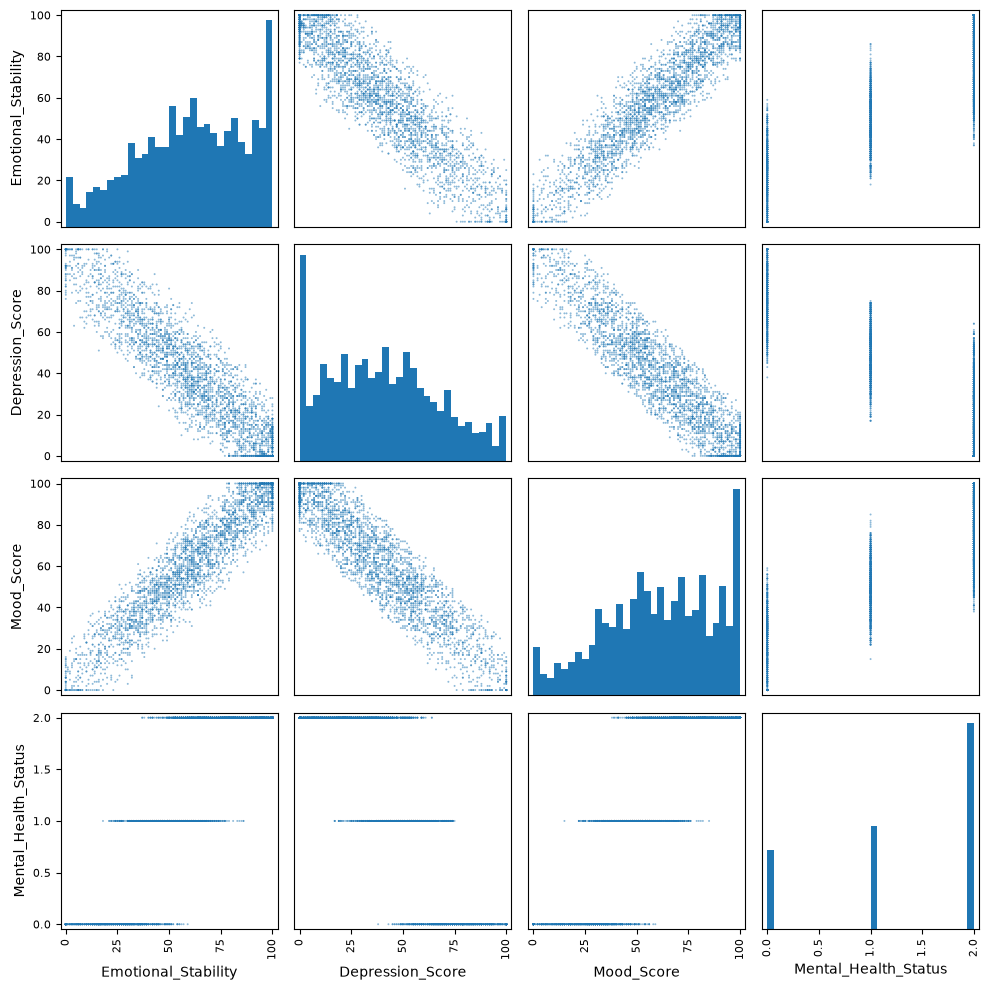

In [98]:
from pandas.plotting import scatter_matrix

cols = ["Emotional_Stability", "Depression_Score", "Mood_Score", "Mental_Health_Status"]

scatter_matrix(df[cols].sample(3000, random_state=1),
               figsize=(10, 10), alpha=0.5, s=8, diagonal="hist", hist_kwds={"bins": 30})
plt.tight_layout()
plt.show()

Матрица для всех

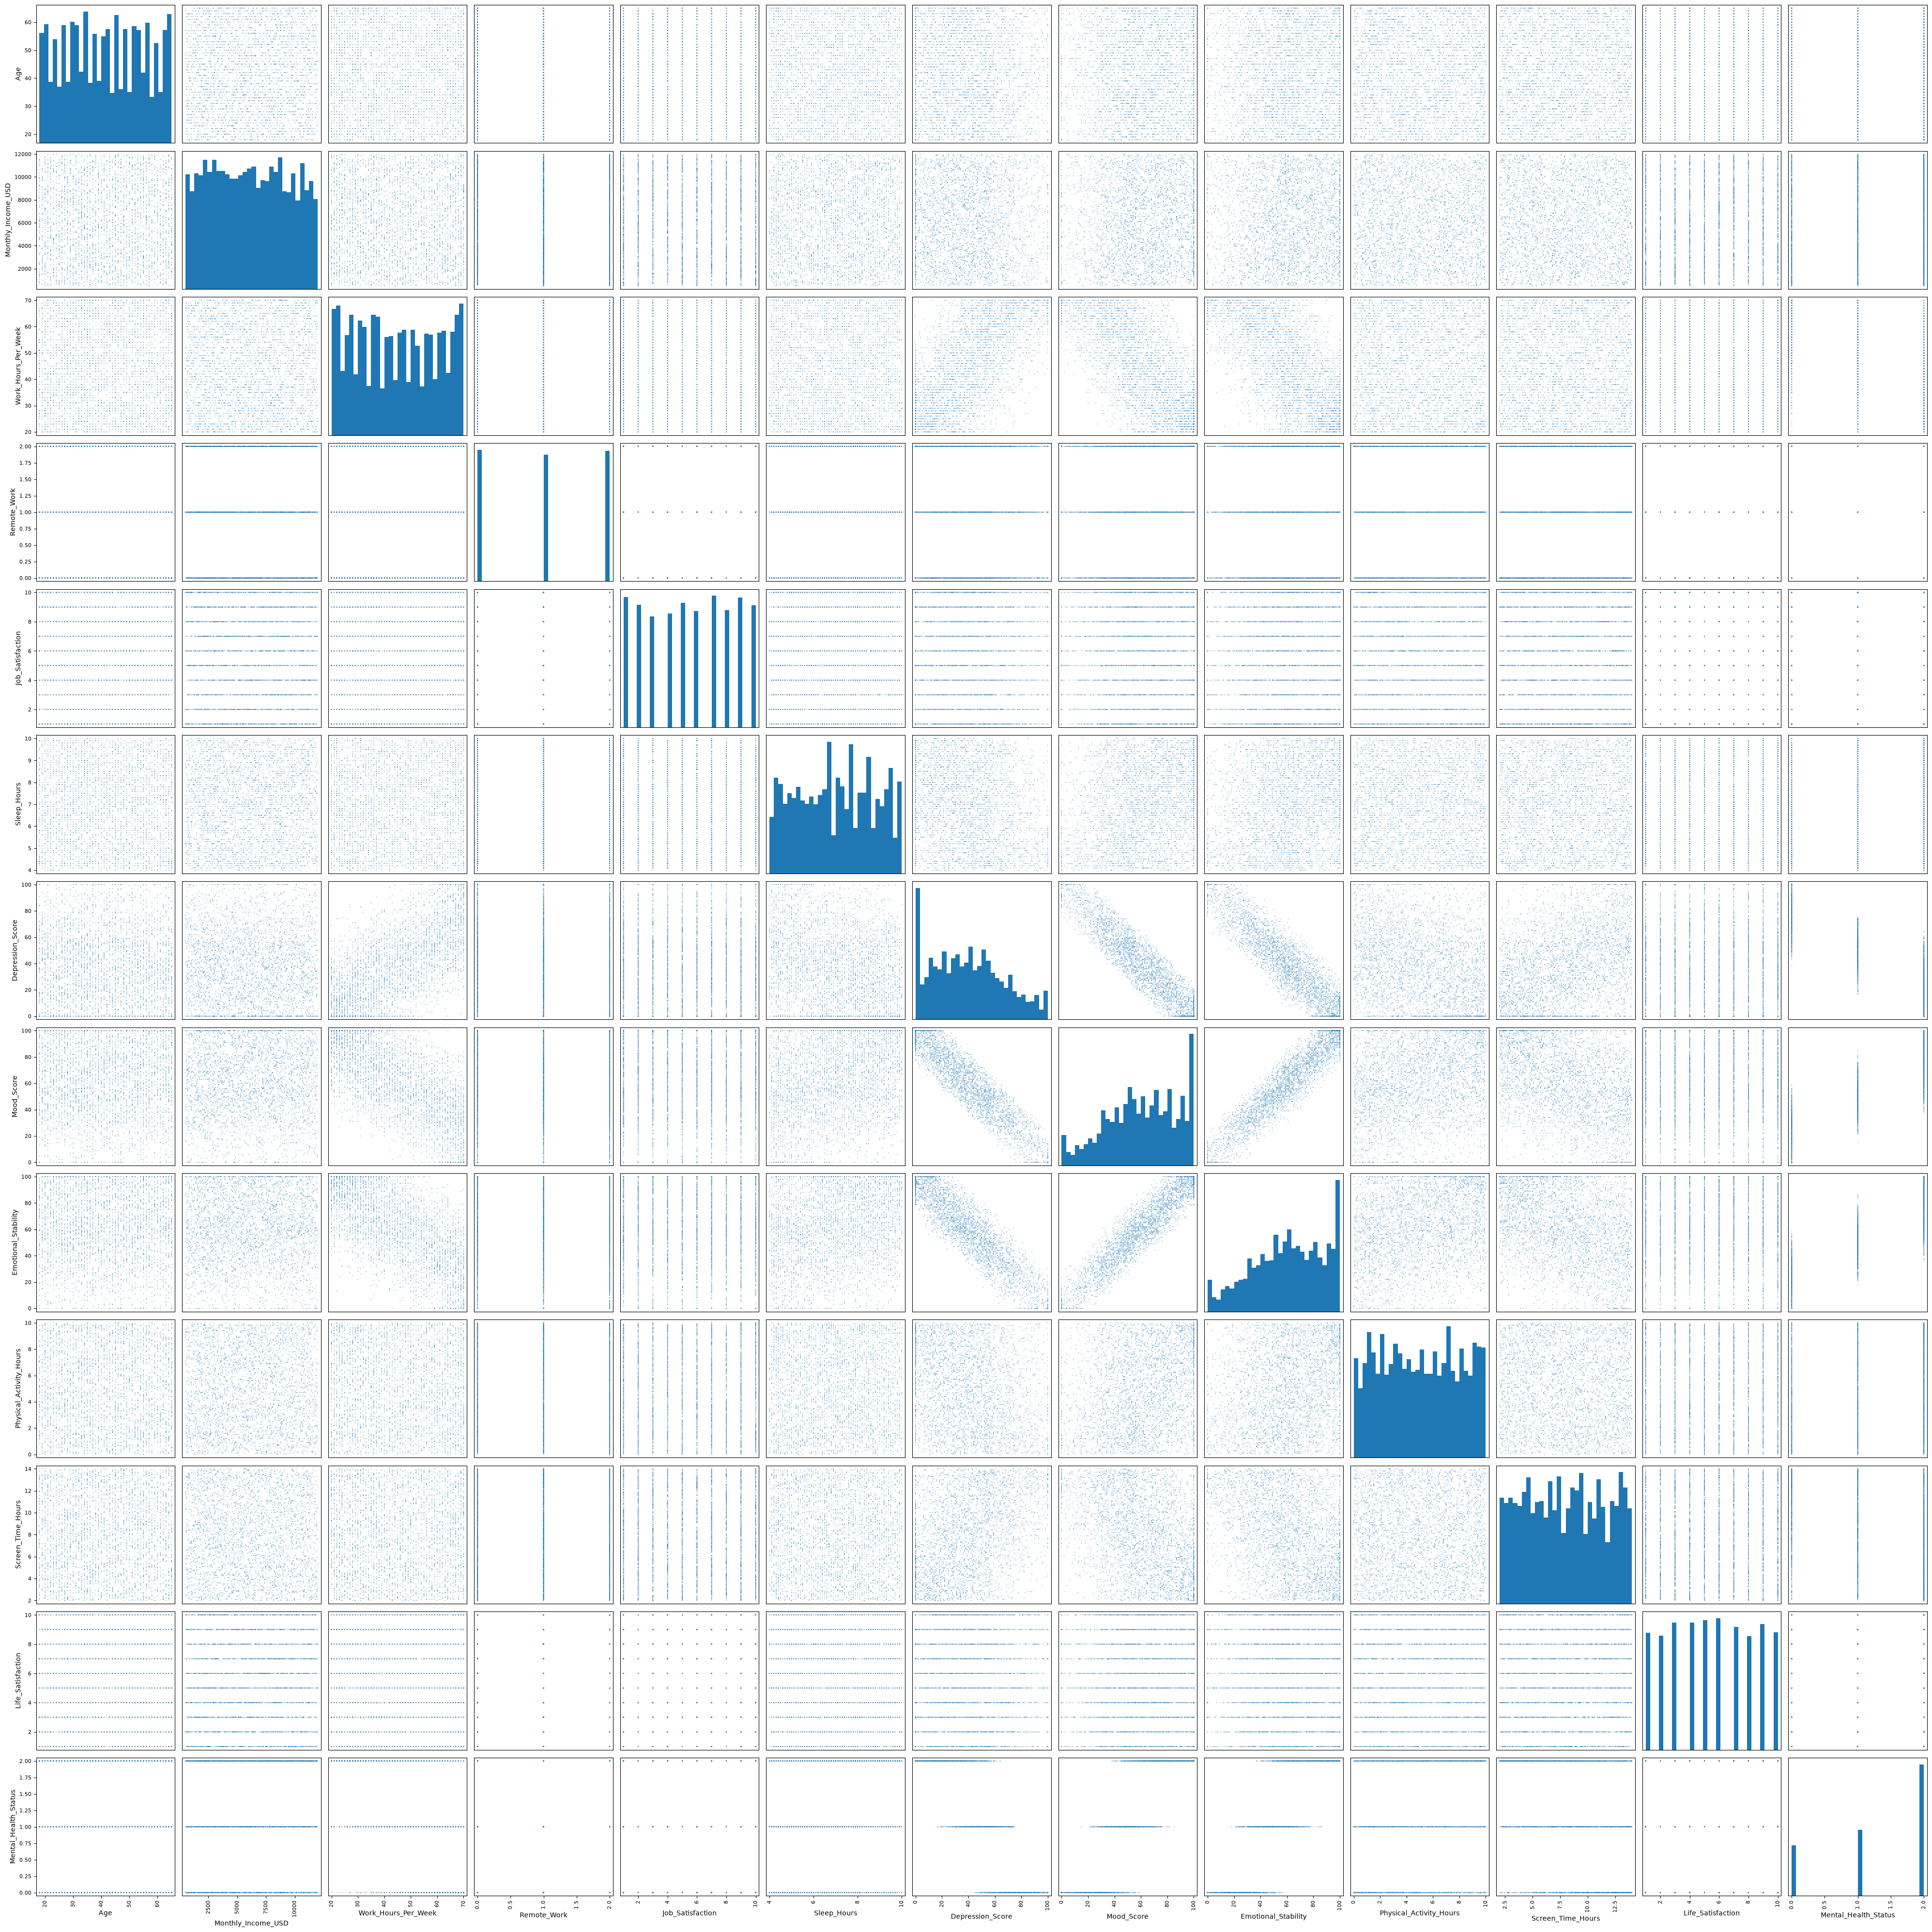

In [99]:
scatter_matrix(df.sample(3000, random_state=1),
               figsize=(40, 40), alpha=0.5, s=8, diagonal="hist", hist_kwds={"bins": 30})
plt.tight_layout()
plt.show()

## Анализ

Самая высокая корреляция ментального здоровья у атрибутов: эмоциональная стабильность (r = 0.84, прямая), баллы по шкале настроения (r = 0.84, прямая), баллы по шкале депрессии (r = −0.84, обратная).

Самая высокая корреляция между остальными атрибутами: настроение и эмоциональная стабильность (r = 0.93, прямая), депрессия и настроение (r = −0.92, обратная), депрессия и эмоциональная стабильность (r = −0.90, обратная). Эти три показателя почти дублируют друг друга.

Умеренная корреляция ментального здоровья с количеством рабочих часов в неделю (r = −0.56, обратная): чем больше рабочих часов, тем хуже состояние. Рабочие часы также связаны с депрессией (r = 0.61, прямая), эмоциональной стабильностью (r = −0.61, обратная) и настроением (r = −0.63, обратная).

Слабая корреляция ментального здоровья с экранным временем (r = −0.31, обратная), часами сна (r = 0.20, прямая) и физической активностью (r = 0.16, прямая). Эти же признаки слабо связаны с настроением, депрессией и эмоциональной стабильностью (|r| от 0.19 до 0.36).

Практически не коррелируют (|r| < 0.013) ни с ментальным здоровьем, ни с большинством остальных атрибутов: возраст, месячный доход, формат работы, удовлетворённость работой и жизнью.

Корреляции между парами признаков, не входящих в перечисленные группы, близки к нулю, что характерно для синтетических данных.